# Idea for the Image processing pipeline

### 1. Preprocessing
* Convert to grayscale with adaptive threshold

### 2. Morphological Operations
* Erosion & Dilation: Remove small noise and preserve only long, continuous structural lines

### 3. Grid Reconstruction
* Hough Lines? to detect lines

### 4. Intersection & Corner Detection
* Locate crossing points by finding pixels present in both the horizontal and vertical masks

### 5. Cell Extraction
* Detect closed contours within the grid

### 6. OCR
* Text Detection on the first row to detect each habit in each cell

### 7. Cross Detection
* On each cell detect if it is crossed or not
  * Ideas:
    * Black White pixel count
    * Diagonal lines

In [5]:
import sys
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

BACKEND_PATH = Path("backend")
if str(BACKEND_PATH) not in sys.path:
    sys.path.insert(0, str(BACKEND_PATH))

from app.table_detection import (
    load_image, resize_to_max, preprocess
)

IMAGE_DIR = Path("tracker-table-images")

def show(img_bgr, title="", figsize=(14, 6), cmap=None):
    plt.figure(figsize=figsize)
    if cmap is None:
        plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) if len(img_bgr.shape) == 3 else img_bgr, cmap="gray")
    else:
        plt.imshow(img_bgr, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

## 1  Load sample images

In [6]:
all_images = sorted(IMAGE_DIR.glob("*.png")) + sorted(IMAGE_DIR.glob("*.jpg"))
print(f"Found {len(all_images)} images:")
for p in all_images:
    print(f"  {p.name}")

Found 4 images:
  convertet.png
  photo-edited.png
  screenshot.png
  from-web.jpg


Original size : 3888×1774
Working size  : 1800×821


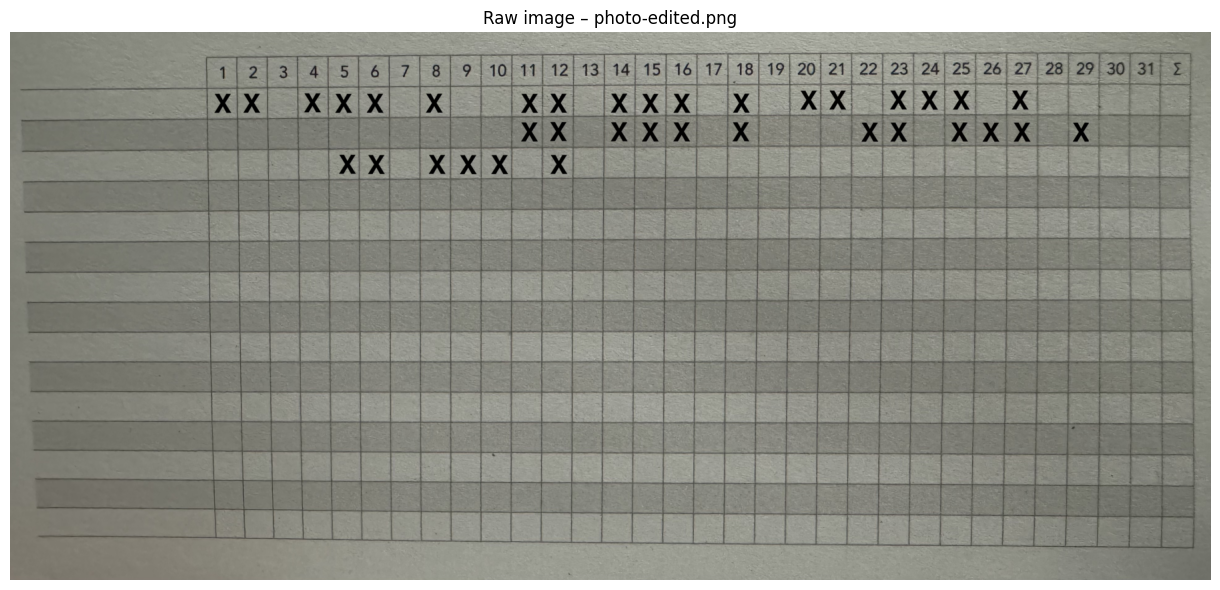

In [7]:
# Pick the image to work with in the step-by-step walk-through
SAMPLE = IMAGE_DIR / "photo-edited.png"

raw = load_image(SAMPLE)
img = resize_to_max(raw, max_dim=1800)
print(f"Original size : {raw.shape[1]}×{raw.shape[0]}")
print(f"Working size  : {img.shape[1]}×{img.shape[0]}")
show(img, f"Raw image – {SAMPLE.name}")

## 2 Preprocess

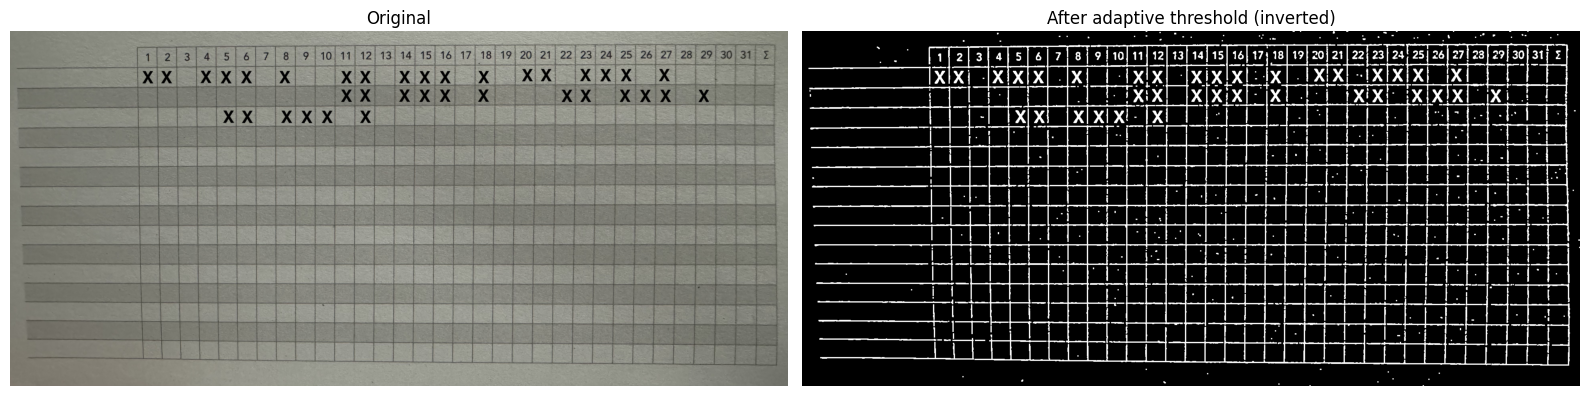

In [8]:
binary = preprocess(img)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(binary, cmap="gray")
axes[1].set_title("After adaptive threshold (inverted)")
axes[1].axis("off")
plt.tight_layout()
plt.show()